Random Forest: an ensemble of decision trees, each trained on a bootstrap sample with a random subset of features per split. Builds directly on `08-decision-trees-sklearn/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (124, 13), Test: (54, 13)


In [2]:
# Single decision tree baseline (no depth limit -> tends to overfit)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
print(f"Single Tree - Train acc: {tree.score(X_train, y_train)*100:.2f}%, Test acc: {tree.score(X_test, y_test)*100:.2f}%")

# Random Forest: many trees, bootstrap samples, random feature subsets, majority vote
rf = RandomForestClassifier(n_estimators=200, random_state=42, oob_score=True)
rf.fit(X_train, y_train)
print(f"Random Forest - Train acc: {rf.score(X_train, y_train)*100:.2f}%, Test acc: {rf.score(X_test, y_test)*100:.2f}%")
print(f"Random Forest - OOB score (free validation estimate): {rf.oob_score_*100:.2f}%")

Single Tree - Train acc: 100.00%, Test acc: 96.30%
Random Forest - Train acc: 100.00%, Test acc: 100.00%
Random Forest - OOB score (free validation estimate): 97.58%


In [3]:
y_pred = rf.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



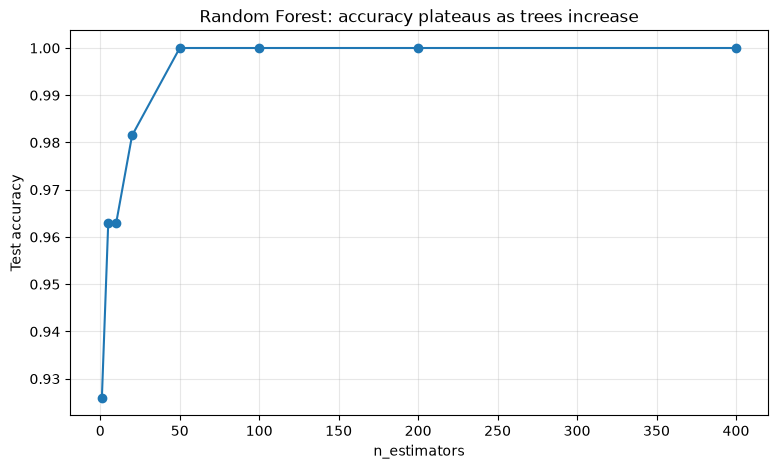

In [4]:
# How many trees do we actually need? Track accuracy as n_estimators grows.
n_estimators_range = [1, 5, 10, 20, 50, 100, 200, 400]
accs = []
for n in n_estimators_range:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    accs.append(m.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_range, accs, 'o-')
plt.xlabel('n_estimators')
plt.ylabel('Test accuracy')
plt.title('Random Forest: accuracy plateaus as trees increase')
plt.grid(True, alpha=0.3)
plt.show()

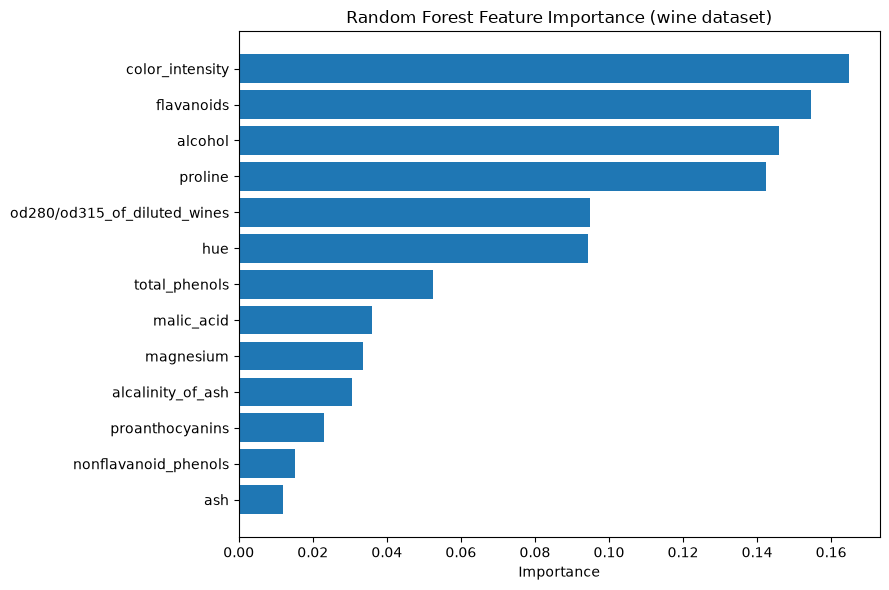

                         feature  importance
9                color_intensity    0.164947
6                     flavanoids    0.154674
0                        alcohol    0.146022
12                       proline    0.142511
11  od280/od315_of_diluted_wines    0.094885
10                           hue    0.094361
5                  total_phenols    0.052453
1                     malic_acid    0.035982
4                      magnesium    0.033691
3              alcalinity_of_ash    0.030471
8                proanthocyanins    0.022934
7           nonflavanoid_phenols    0.015116
2                            ash    0.011953


In [5]:
# Feature importance -- averaged across all trees in the forest
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importances['feature'], importances['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance (wine dataset)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(importances)

In [6]:
# Bagging in action: each tree sees a different bootstrap sample.
# Show how individual trees disagree while the forest vote is stable.
sample_idx = 0
individual_preds = [t.predict(X_test[[sample_idx]])[0] for t in rf.estimators_[:20]]
print(f"True label: {y_test[sample_idx]} ({wine.target_names[y_test[sample_idx]]})")
print(f"First 20 trees' predictions: {individual_preds}")
print(f"Forest's majority vote: {rf.predict(X_test[[sample_idx]])[0]}")
print(f"Forest's predicted probabilities: {rf.predict_proba(X_test[[sample_idx]])[0]}")

True label: 0 (class_0)
First 20 trees' predictions: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Forest's majority vote: 0
Forest's predicted probabilities: [0.97 0.02 0.01]
